# Feature Engineering

Preguntas de investigación del artículo:
1. ¿Qué tan precisas pueden ser predicciones de las desviacione en tiempo y costo en proyectos de infraestructura?
2. ¿Que tan relevantes pueden ser los diferentes grupos de variables del proyecto: características del proyecto y el proceso de contratación, indicadores de desempeño de la entidad, indicadores de desempeño del contratista, y variablex exogenas?
3. Caules son las principales características del proyecto que determinan las desviaciones
4. Caules son los principales indicadores de la entidad para determinar proyecto que determinan las desviaciones
5. Caules son los principales indicadores del contratista para determinar proyecto que determinan las desviaciones
6. Caules son las principales variables exogenas para determinar proyecto que determinan las desviaciones



In [149]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [150]:
!pip install optuna --quiet
!pip install optuna-integration[sklearn]
!pip install fuzzywuzzy --quiet
!pip install recordlinkage --quiet
!pip install jellyfish --quiet
!pip install python-Levenshtein

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)

In [152]:
# Configurar conexion con google drive y con carpeta de google colab
from google.colab import drive
drive.mount('/content/drive')
workin_dir = '/content/drive/MyDrive/Colab Notebooks/Prediccion de Adiciones Proyectos de Infraestructura'
os.chdir(workin_dir)
import sys
# Add the directory containing the .py file to the Python path
sys.path.append(workin_dir) # Replace with the actual path if different

# Now you can import functions from your .py file
from ml_pipeline import create_preprocessing_pipeline

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Carga de Datos

In [153]:
# Carga de Datos
df = pd.read_csv('Data/contratosSECOPCleaned.csv')   # Load the data
df.info()

<ipython-input-153-18273f62db4d>:2: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Data/contratosSECOPCleaned.csv')   # Load the data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30993 entries, 0 to 30992
Data columns (total 48 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   uid                        30993 non-null  object 
 1   buyerName                  30993 non-null  object 
 2   buyerId                    30993 non-null  object 
 3   buyerDepartment            30993 non-null  object 
 4   buyerLevel                 30993 non-null  object 
 5   contractMethodCountryLaw   30993 non-null  object 
 6   contractType               30993 non-null  object 
 7   contractDescription        30993 non-null  object 
 8   contractTotalValue         30993 non-null  float64
 9   contractDateSigned         30993 non-null  object 
 10  contractStartDate          30993 non-null  object 
 11  contractEndDate            30993 non-null  object 
 12  urlTender                  30993 non-null  object 
 13  supplierId                 30992 non-null  obj

In [154]:
print(df.head())

                  uid                                          buyerName  \
0  CO1.PCCNTR.5582573  SENA REGIONAL GUAJIRA GRUPO MIXTO DE APOYO ADM...   
1   CO1.PCCNTR.539999                                 MUNICIPIO DE HONDA   
2  CO1.PCCNTR.1095329           GOBERNACION DE CALDAS - PRIMERO LA GENTE   
3  CO1.PCCNTR.3959080                ALCALDIA MUNICIPAL DE RESTREPO META   
4  CO1.PCCNTR.2510789                                MUNICIPIO DE TUNJA/   

     buyerId buyerDepartment   buyerLevel  \
0  899999034      LA GUAJIRA     NATIONAL   
1  800100058          TOLIMA  TERRITORIAL   
2  890801052          CALDAS  TERRITORIAL   
3  800098199            META  TERRITORIAL   
4  891800846          BOYACA  TERRITORIAL   

               contractMethodCountryLaw contractType  \
0  SELECCION ABREVIADA DE MENOR CUANTIA         OBRA   
1  SELECCION ABREVIADA DE MENOR CUANTIA         OBRA   
2  SELECCION ABREVIADA DE MENOR CUANTIA         OBRA   
3       LICITACION PUBLICA OBRA PUBLICA         

# Metodología

1. Limpieza de datos
2. Datos extremos
3. Ingeniería de variables (año electoral, etc.)
4. Indicadores de la entidad
5. Indicadores de los contratistas
6. Variables exogenas (Terridata, otras fuentes)

In [155]:
df.isnull().sum()

,0
uid,0
buyerName,0
buyerId,0
buyerDepartment,0
buyerLevel,0
contractMethodCountryLaw,0
contractType,0
contractDescription,0
contractTotalValue,0
contractDateSigned,0


# Procesamiento de datos

**Lista de tareas de limpieza**

- Eliminar contratos con desviación en costo superior al 50% (No se permite por ley)
- Transformación logaritmica a la variable valor del contrato
- Quitar contratos de menos de un mes de duración (No tiene sentido para contratos de obra)
- Quitar valores extremos en las desviaciones en tiempo (Arriba del percentil 99%)
- Quitar contratos cuyo award growth se encuentra por del -100% o arriba del 20%
- Quitar valores extremos en el project intensity (Arriba del percentil 99%)
- Quitar contratos firmado en 2024 (no representativos en la muestra)
- Quitar contratos que registren una duración superior a los 5 años

## Entidades públicas

In [156]:
df['buyerName'].value_counts().head(20)

,count
buyerName,
CARDIQUE - CORPORACION AUTONOMA REGIONAL DEL CANAL DEL DIQUE,497
NORTE DE SANTANDER - GOBERNACION,258
CALDAS - EMPRESA DE OBRAS SANITARIAS DE CALDAS,236
ANTIOQUIA - GOBERNACION,215
INSTITUTO COLOMBIANO DE BIENESTAR FAMILIAR (ICBF),186
VALLE DEL CAUCA - ALCALDIA MUNICIPIO DE CALI,183
SANTANDER - ALCALDIA MUNICIPIO DE BUCARAMANGA,177
CAUCA - GOBERNACION,172
SANTANDER - GOBERNACION,161


## Bid-Contract Ratio

In [157]:
# Calculate el bid
df['bidContractRatio'] = df['contractValueMw'] / df['tenderValueMw']

In [158]:
# Summary of bid contract ratio
print(df['bidContractRatio'].describe())

count    30993.000000
mean         1.342439
std         16.319911
min          0.000972
25%          0.996886
50%          0.999853
75%          1.000000
max       1000.000000
Name: bidContractRatio, dtype: float64


In [159]:
# Count the the bid contract ratio below of 0.7 and above of 1.3
print('Bid contract ratio below of 0.7: {}'.format(sum(df['bidContractRatio'] < 0.7)))
print('Bid contract ratio above of 1.3: {}'.format(sum(df['bidContractRatio'] > 1.3)))

Bid contract ratio below of 0.7: 431
Bid contract ratio above of 1.3: 127


In [160]:
# Filter the bid contract ratio below of 0.7 and above of 1.3
df = df.loc[(df['bidContractRatio'] > 0.7) & (df['bidContractRatio'] < 1.3)]

In [161]:
df.shape

(30435, 49)


## Cost Deviation

In [162]:
print(df['costDeviationPerc'].describe())

count    30435.000000
mean         0.086233
std          1.586373
min         -0.575244
25%          0.000000
50%          0.000000
75%          0.034607
max        249.728140
Name: costDeviationPerc, dtype: float64


In [163]:
# Print cost deviation percent above of 50% and below of 0%
# Print each count
print('Cost deviation percent above of 50%: {}'.format(sum(df['costDeviationPerc'] > 0.5)))
print('Cost deviation percent below of 0%: {}'.format(sum(df['costDeviationPerc'] < 0)))

Cost deviation percent above of 50%: 249
Cost deviation percent below of 0%: 50


In [164]:
# Filter contracts with less of 50% of cost deviation
df = df.loc[(df['costDeviationPerc'] >= 0.0) & (df['costDeviationPerc'] <= 0.5)]

In [165]:
# Cost deviation level low <= 0.05, medium > 0.05 and <= 0.20, high > 0.20
df['costDeviationLevel'] = 'low'
df.loc[(df['costDeviationPerc'] > 0.05) & (df['costDeviationPerc'] <= 0.20), 'costDeviationLevel'] = 'medium'
df.loc[df['costDeviationPerc'] > 0.20, 'costDeviationLevel'] = 'high'
df['costDeviationLevel'] = df['costDeviationLevel'].astype('category')

In [166]:
# Count cost deviation level
print(df['costDeviationLevel'].value_counts())

costDeviationLevel
low       23083
high       4234
medium     2819
Name: count, dtype: int64


In [167]:
df.shape

(30136, 50)

## Project duration

In [168]:
# Project with duration below of 30 days
print('Project with duration below of 30 days: {}'.format(sum(df['contractDurationDays'] < 30)))
# Project with duration above of 5 years
print('Project with duration above of 5 years: {}'.format(sum(df['contractDurationDays'] > 360*5)))

Project with duration below of 30 days: 1452
Project with duration above of 5 years: 18


In [169]:
# Filter contracts with almost 30 days and less of 5 years of duration
df = df.loc[(df['contractDurationDays'] >= 30) & (df['contractDurationDays'] < 360*5)]

In [170]:
df.shape

(28665, 50)

## Detección de datos atípicos

In [171]:
df.columns

Index(['uid', 'buyerName', 'buyerId', 'buyerDepartment', 'buyerLevel',
       'contractMethodCountryLaw', 'contractType', 'contractDescription',
       'contractTotalValue', 'contractDateSigned', 'contractStartDate',
       'contractEndDate', 'urlTender', 'supplierId', 'isBusinessGroup',
       'isSME', 'isPostConflictContract', 'buyerLocation', 'supplierName',
       'tenderStatus', 'contractYearSigned', 'tenderValue', 'contractValue',
       'supplierDepartment', 'awardId', 'contractAditionalValue',
       'databaseSource', 'contractMonthSigned', 'contractMonthStart',
       'contractMonthEnd', 'tenderValueMw', 'contractValueMw',
       'contractAditionalValueMw', 'contractTotalValueMw',
       'contractDurationDays', 'contractAditionalDuration',
       'contractTotalDuration', 'haveCostDeviation', 'haveTimeDeviation',
       'haveTimeAndCostDeviation', 'projectIntensity', 'projectIntensityMw',
       'awardGrowth', 'costDeviationPerc', 'timeDeviationPerc', 'buyerRegion',
       'con

In [172]:
# Train isolation forest for outlier detection
vars_out_predict = ['buyerDepartment', 'buyerLevel','isBusinessGroup','isSME',
                    'contractYearSigned','supplierDepartment',
                    'tenderValueMw', 'contractValueMw','contractAditionalValueMw','contractTotalValueMw',
                    'contractDurationDays', 'contractAditionalDuration','contractTotalDuration',
                    'haveCostDeviation', 'haveTimeDeviation','haveTimeAndCostDeviation',
                    'projectIntensityMw','awardGrowth','costDeviationPerc', 'timeDeviationPerc', 'buyerRegion',
                    'contractMethodType', 'supplierRegion', 'bidContractRatio']
X = df[vars_out_predict].copy()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns
preprocesor = create_preprocessing_pipeline(numeric_columns=num_cols, categorical_columns=cat_cols)
outlier_model = IsolationForest(contamination=0.01)
pipe_model = Pipeline(
    [
        ('preprocesor', preprocesor),
        ('classifier', outlier_model)
    ]
)
pipe_model.fit(X)
pred_outlier = pipe_model.predict(X)
df['outlier'] = [1 if i == -1 else 0 for i in pred_outlier]

In [173]:
df['outlier'].value_counts()

,count
outlier,
0,28378
1,287


In [174]:
df[['tenderValueMw', 'contractValueMw','contractAditionalValueMw','contractTotalValueMw',
     'contractDurationDays', 'contractAditionalDuration','contractTotalDuration',
     'projectIntensityMw','awardGrowth','costDeviationPerc', 'timeDeviationPerc',
    'bidContractRatio','outlier']].groupby('outlier').describe()

tenderValueMw                                                      \
                count          mean           std        min          25%   
outlier                                                                     
0             28378.0   1308.147402   3574.405779  27.827170   168.569221   
1               287.0  34876.756254  71500.991187  33.366878  6527.938805   

                                                  contractValueMw  \
                 50%           75%            max           count   
outlier                                                             
0          337.97441   1023.277369  128744.543892         28378.0   
1        17708.06101  36566.844950  980523.007682           287.0   

                                                                           \
                 mean           std        min          25%           50%   
outlier                                                                     
0         1299.599310   3582.311241  27.765372   167.469875    335.028867   
1        34234.490373  68359.659451  30.030191  6335.180750  17265.380154   

                                     contractAditionalValueMw              \
                  75%            max                    count        mean   
outlier                                                                     
0         1013.636090  144808.177693                  28378.0    80.23922   
1        38296.265458  923750.759375                    287.0  5398.05797   

                                                                               \
                 std  min         25%          50%          75%           max   
outlier                                                                         
0         353.121668  0.0    0.000000     0.000000     6.861040   9285.717151   
1        9902.820812  0.0  114.875733  2074.283313  6512.350231  94621.874494   

        contractTotalValueMw                                         \
                       count          mean           std        min   
outlier                                                               
0                    28378.0   1379.838530   3699.139351  38.534248   
1                      287.0  39632.548343  75041.923488  44.918413   

                                                                \
                 25%           50%           75%           max   
outlier                                                          
0         176.075864    360.670325   1083.002168  1.448082e+05   
1        7779.537680  22586.844361  42247.913752  1.018373e+06   

        contractDurationDays                                              \
                       count        mean         std   min    25%    50%   
outlier                                                                    
0                    28378.0  106.093981   75.598306  30.0   60.0   90.0   
1                      287.0  346.439024  239.544269  30.0  180.0  330.0   

                       contractAditionalDuration                               \
           75%     max                     count        mean         std  min   
outlier                                                                         
0        120.0  1350.0                   28378.0   21.088977   56.333835  0.0   
1        428.0  1740.0                     287.0  216.313589  252.120335  0.0   

                                    contractTotalDuration              \
         25%    50%     75%     max                 count        mean   
outlier                                                                 
0        0.0    0.0   16.75  1800.0               28378.0  127.182959   
1        0.0  175.0  330.00  1577.0                 287.0  562.752613   

                                                       projectIntensityMw  \
                std   min    25%    50%    75%     max              count   
outlier                                                                     
0        103.024759  30.0  

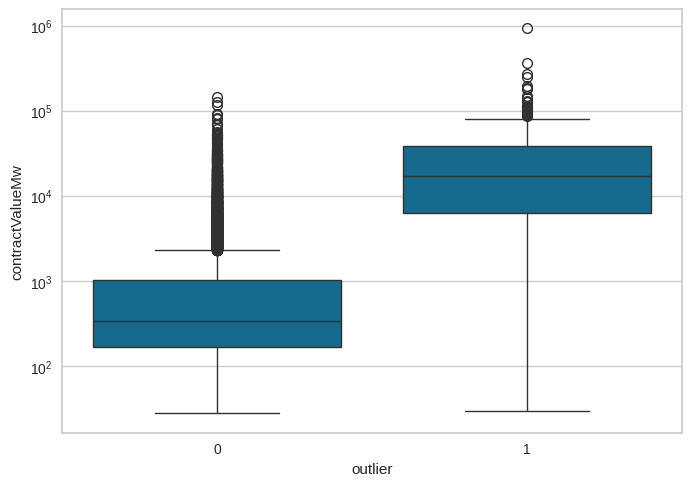

In [175]:
sns.boxplot(x='outlier', y='contractValueMw', data=df)
plt.yscale('log')
plt.show()

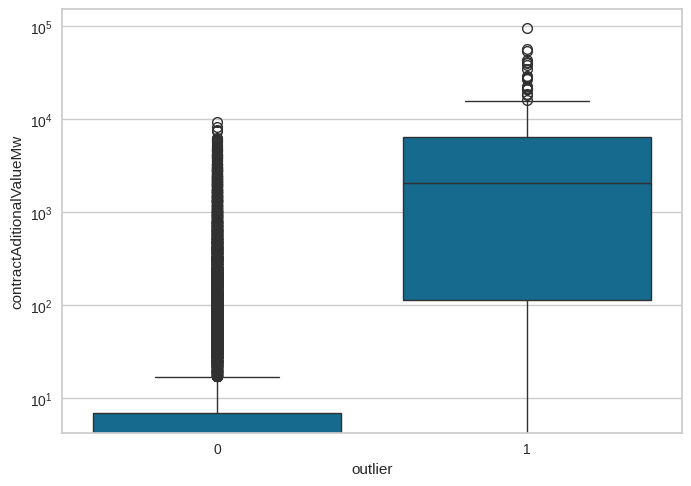

In [176]:
sns.boxplot(x='outlier', y='contractAditionalValueMw', data=df)
plt.yscale('log')
plt.show()

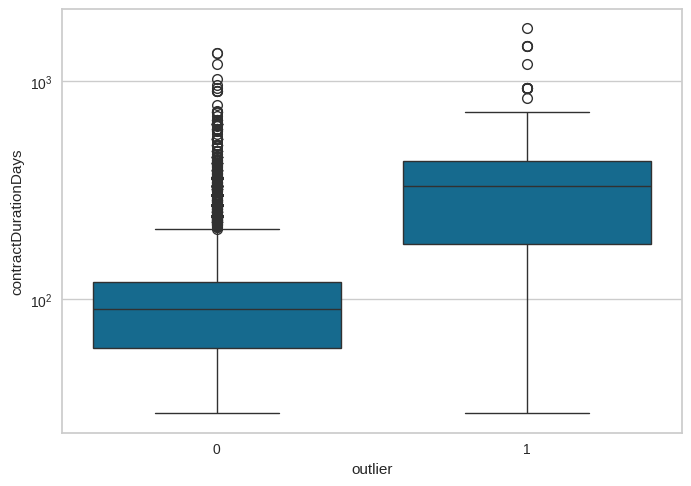

In [177]:
sns.boxplot(x='outlier', y='contractDurationDays', data=df)
plt.yscale('log')
plt.show()

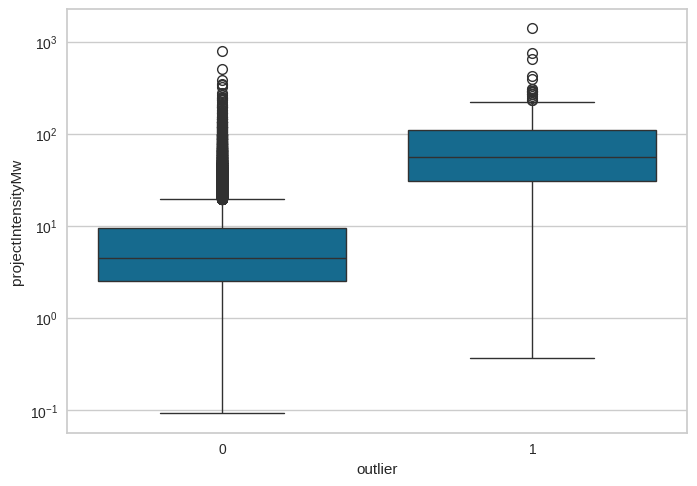

In [178]:
sns.boxplot(x='outlier', y='projectIntensityMw', data=df)
plt.yscale('log')
plt.show()

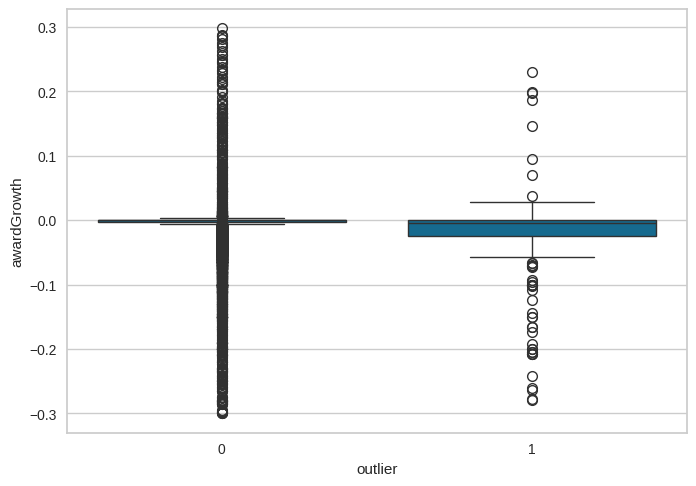

In [179]:
sns.boxplot(x='outlier', y='awardGrowth', data=df)
plt.show()

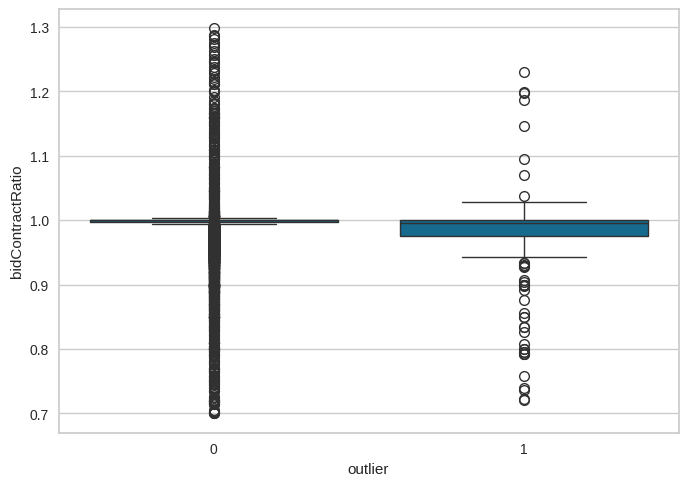

In [180]:
sns.boxplot(x='outlier', y='bidContractRatio', data=df)
plt.show()

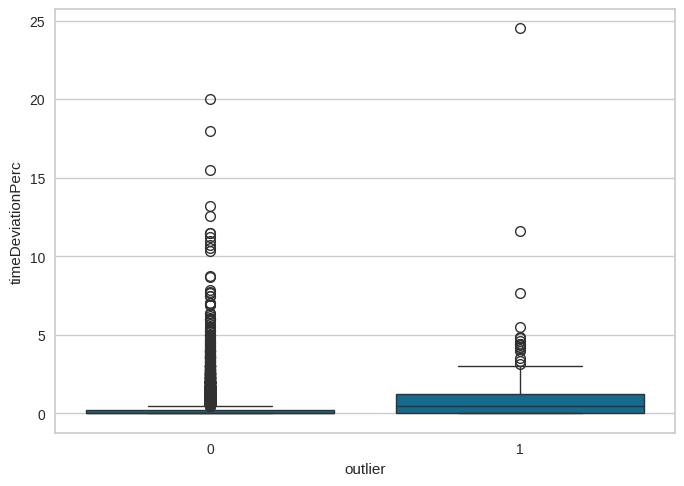

In [181]:
sns.boxplot(x='outlier', y='timeDeviationPerc', data=df)
plt.show()

In [182]:
# Filtrar datos atípicos
df = df.loc[df['outlier'] == 0].copy()
df.shape

(28378, 51)

## Year Signed

In [183]:
# Definir una variable para el año terminación del contrato
df['contractEndDate'] = pd.to_datetime(df['contractEndDate'])

# Year of end contract
df['contractYearEnd'] = df['contractEndDate'].dt.year

In [184]:
print(
    df.groupby(['contractYearSigned'])
    .size()
    .reset_index(name='n')
    .assign(p = lambda x: x['n']/x['n'].sum())
)

    contractYearSigned     n         p
0                 2014  3239  0.114138
1                 2015  4369  0.153957
2                 2016  1886  0.066460
3                 2017  3395  0.119635
4                 2018  3494  0.123124
5                 2019  4089  0.144090
6                 2020  1452  0.051166
7                 2021  2467  0.086934
8                 2022  2145  0.075587
9                 2023  1771  0.062407
10                2024    71  0.002502


## Ajustar algunos municipios y departamentos

In [185]:
buyerbuyerDepartment = {'BOGOTA D.C.': 'BOGOTA'}
buyerLocation = {'BOGOTA D.C.': 'BOGOTA',
                 'SAN JOSE DE CUCUTA': 'CUCUTA',
                 'VILLA GARZON/VILLA AMAZONICA': 'VILLAGARZON',
                 'PAEZ/BELALCAZAR': 'PAEZ'}
df['buyerDepartment'] = df['buyerDepartment'].replace(buyerbuyerDepartment)
df['buyerLocation'] = df['buyerLocation'].replace(buyerLocation)

## Electoral and preelectoral year

In [186]:
# Electoral year
anno_electoral_presidente = [i for i in np.arange(2010,2024,4)]
df['electoralYear'] = df['contractYearSigned'].apply(lambda x: 1 if x in anno_electoral_presidente else 0)
print(df['electoralYear'].value_counts())

electoralYear
0    19500
1     8878
Name: count, dtype: int64


In [187]:
# Preelectoral year
preelectoral_year = [i for i in np.arange(2009,2024,4)]
df['preelectoralYear'] = df['contractYearSigned'].apply(lambda x: 1 if x in preelectoral_year else 0)
print(df['preelectoralYear'].value_counts())

preelectoralYear
0    22516
1     5862
Name: count, dtype: int64


## Work Category

In [188]:
def workCategory(df):
    # Asignar tipo de obra
    df['workCategoryConstruction'] = df['contractDescription'].str.contains('CONSTRUCCION|PAVIMENTACION|COSNTRUCCION|COSNTRUCCION|CONTRUCCION|CONSTRUIR|ADECUACUACION|EDIFICACION|EDIFICAR|ADECUAR|CONSTRUCION')
    df['workCategoryMaintenance'] = df['contractDescription'].str.contains('MANTENIMIENTO|MANTEMIENTO|MANTENER|MANTEMIENTO|MATENIMIENTO|MANTANIMIENTO|MANTENIIENTO|MATENIMIENTO|MANTANIMIENTO|MANTANIMIENTO|MANTENIIENTO')
    df['workCategoryRehabilitation'] = df['contractDescription'].str.contains('REHABILITACION|REHABILITAR|REHABLITACION|RECUPERACION|REHABLITACION|REPARACION|REPARAR')
    df['workCategoryImprovement'] = df['contractDescription'].str.contains('MEJORAMIENTO|MEJORAR|MEJORAMENTO|MEJORAMAIENTO|MEKJORAMIENTO|MEJORAMAIENTO|MEJORAMENTO|MEKJORAMIENTO|MEJORAMENTO|OPTIMIZACION|AMPLIACION|EXPANSION|EXPANDIR|OPTIMIZAR|AMPLIAR')
    df['totalWorkCategory'] = np.int32(df['workCategoryConstruction'] + df['workCategoryMaintenance'] + df['workCategoryRehabilitation'] + df['workCategoryImprovement'])
    df['workCategoryOthers'] = df['totalWorkCategory'] == 0

    # Lista de columnas de tipos de obra
    workCategory = ['workCategoryConstruction',
                    'workCategoryMaintenance',
                    'workCategoryRehabilitation',
                    'workCategoryImprovement',
                    'workCategoryOthers']

    # Crear columna WORK_TYPE
    df['workCategory'] = ''

    # Asignar los valores correspondientes a WORK_TYPE
    for col in workCategory:
        df.loc[df[col] == True, 'workCategory'] = col.replace('workCategory', '')

    df.drop(columns=workCategory + ['totalWorkCategory'], inplace=True)

    #df = df.loc[~df['workCategory'].isin(['Others'])].copy()

    #workCategoryOrder = ['Construction', 'Improvement', 'Rehabilitation', 'Maintenance']
    #df['workCategory'] = pd.Categorical(df['workCategory'], categories=workCategoryOrder, ordered=True)

    return df

In [189]:
df = workCategory(df)
df

,uid,buyerName,buyerId,buyerDepartment,buyerLevel,contractMethodCountryLaw,contractType,contractDescription,contractTotalValue,contractDateSigned,contractStartDate,contractEndDate,urlTender,supplierId,isBusinessGroup,isSME,isPostConflictContract,buyerLocation,supplierName,tenderStatus,contractYearSigned,tenderValue,contractValue,supplierDepartment,awardId,contractAditionalValue,databaseSource,contractMonthSigned,contractMonthStart,contractMonthEnd,tenderValueMw,contractValueMw,contractAditionalValueMw,contractTotalValueMw,contractDurationDays,contractAditionalDuration,contractTotalDuration,haveCostDeviation,haveTimeDeviation,haveTimeAndCostDeviation,projectIntensity,projectIntensityMw,awardGrowth,costDeviationPerc,timeDeviationPerc,buyerRegion,contractMethodType,supplierRegion,bidContractRatio,costDeviationLevel,outlier,contractYearEnd,electoralYear,preelectoralYear,workCategory
0,CO1.PCCNTR.5582573,SENA REGIONAL GUAJIRA GRUPO MIXTO DE APOYO ADM...,899999034,LA GUAJIRA,NATIONAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,ADECUACION Y REMODELACION DE ESPACIOS PARA PUN...,570872051.0,2023-11-27,2023-11-30,2023-12-30,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,NO DEFINIDO,1,NO,0,RIOHACHA,CONSORCIO GUAJIRA,TERMINADO,2023,575852191.0,570872051.0,NO DEFINIDO,CO1.AWD.1771885,0.0,SECOPII,11,11,12,496.424303,492.131078,0.000000,492.131078,30.0,0,30.0,0,0,0,1.902907e+07,16.404369,-0.008648,0.000000,0.000000,CARIBE,SIMPLIFIED,OTHER,0.991352,low,0,2023,0,0,Others
1,CO1.PCCNTR.539999,MUNICIPIO DE HONDA,800100058,TOLIMA,TERRITORIAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,OBRA CIVIL PARA LA PAVIMENTACION DE LA CARRERA...,252937734.0,2019-10-03,2018-09-19,2018-11-16,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,NO DEFINIDO,1,YES,0,HONDA,CONSORCIO INFRAESTRUCTURAS 2018,TERMINADO,2019,217769000.0,217736210.0,NO DEFINIDO,CO1.AWD.340443,35201524.0,SECOPII,10,9,11,262.969198,262.929602,42.507963,305.437564,60.0,0,60.0,1,0,0,3.628937e+06,4.382160,-0.000151,0.161671,0.000000,ANDINA,SIMPLIFIED,OTHER,0.999849,medium,0,2018,0,0,Construction
2,CO1.PCCNTR.1095329,GOBERNACION DE CALDAS - PRIMERO LA GENTE,890801052,CALDAS,TERRITORIAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,ADECUACIONES MENORES PARA GARANTIZAR LA OPERAT...,98595810.0,2019-09-16,2019-09-16,2019-12-15,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,800250918,0,YES,0,NO DEFINIDO,ACUAMEUNIERSAS,TERMINADO,2019,99676915.0,98595810.0,BOGOTA D.C.,CO1.AWD.581614,0.0,SECOPII,9,9,12,120.365885,119.060385,0.000000,119.060385,90.0,0,90.0,0,0,0,1.095509e+06,1.322893,-0.010846,0.000000,0.000000,ANDINA,SIMPLIFIED,ANDINA,0.989154,low,0,2019,0,0,Others
3,CO1.PCCNTR.3959080,ALCALDIA MUNICIPAL DE RESTREPO META,800098199,META,TERRITORIAL,LICITACION PUBLICA OBRA PUBLICA,OBRA,MEJORAMIENTO DE LA VIA QUE CONDUCE AL INTERNAD...,471315124.0,2022-09-02,2022-09-22,2023-02-25,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,901629203,1,YES,0,RESTREPO,CONSORCIO ESFUERZO VERTICAL PLV,TERMINADO,2022,488303830.0,471315124.0,NO DEFINIDO,CO1.AWD.1380033,0.0,SECOPII,9,9,2,488.303830,471.315124,0.000000,471.315124,120.0,0,120.0,0,0,0,3.927626e+06,3.927626,-0.034791,0.000000,0.000000,ORINOQUIA,OPEN,OTHER,0.965209,low,0,2023,1,0,Improvement
4,CO1.PCCNTR.2510789,MUNICIPIO DE TUNJA/,891800846,BOYACA,TERRITORIAL,MINIMA CUANTIA,OBRA,SI-100 - ADECUACION DEL TERRENO PARA LA CONSTR...,55602870.0,2021-05-14,2021-07-27,2021-09-03,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,7183019,0,YES,0,TUNJA,EDWIN FERNANDO RIVERA OROZCO,TERMINADO,2021,40070955.0,37104704.0,BOYACA,CO1.AWD.1012341,18498166.0,SECOPII,5,7,9,44.105458,40.840553,20.360635,61.201187,40.0,0,40.0,1,0,0,9.276176e+05,1.021014,-0.074025,0.498540,0.000000,ANDINA,LIMITED,ANDINA,0.925975,high,0,2021,0,1,Construction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30987,14-11-2802420-2833890

# Indicadores Históricos de la entidad

## Herfindahl-Hirschman Index

In [190]:
# Funciones para calcular el HHI
def calcular_hhi(df):
    """
    Calcula el Índice Herfindahl Hirschman (HHI) por año y entidad pública
    para el número de contratos y para el valor de los contratos.

    Args:
        df: DataFrame con datos de contratos

    Returns:
        Dos DataFrames con los HHI calculados
    """
    # Aseguramos que existe la columna del año de firma
    if 'contractYearSigned' not in df.columns:
        raise ValueError("No se encontró la columna 'contractYearSigned'.")

    # Usamos directamente la columna contractYearSigned como el año
    df['year'] = df['contractYearSigned']

    # 1. Cálculo del HHI por número de contratos
    contratos_por_proveedor = df.groupby(['year', 'buyerName', 'supplierName'])['uid'].count().reset_index()
    contratos_por_proveedor.rename(columns={'uid': 'num_contratos'}, inplace=True)

    total_contratos = contratos_por_proveedor.groupby(['year', 'buyerName'])['num_contratos'].sum().reset_index()
    total_contratos.rename(columns={'num_contratos': 'total_contratos'}, inplace=True)

    contratos_por_proveedor = pd.merge(contratos_por_proveedor, total_contratos, on=['year', 'buyerName'])
    contratos_por_proveedor['porcentaje'] = (contratos_por_proveedor['num_contratos'] / contratos_por_proveedor['total_contratos']) * 100

    contratos_por_proveedor['porcentaje_cuadrado'] = contratos_por_proveedor['porcentaje'] ** 2
    hhi_num_contratos = contratos_por_proveedor.groupby(['year', 'buyerName'])['porcentaje_cuadrado'].sum().reset_index()
    hhi_num_contratos.rename(columns={'porcentaje_cuadrado': 'hhi_num'}, inplace=True)

    # 2. Cálculo del HHI por valor de contratos
    valor_por_proveedor = df.groupby(['year', 'buyerName', 'supplierName'])['contractValue'].sum().reset_index()

    total_valor = valor_por_proveedor.groupby(['year', 'buyerName'])['contractValue'].sum().reset_index()
    total_valor.rename(columns={'contractValue': 'total_valor'}, inplace=True)

    valor_por_proveedor = pd.merge(valor_por_proveedor, total_valor, on=['year', 'buyerName'])
    valor_por_proveedor['porcentaje'] = (valor_por_proveedor['contractValue'] / valor_por_proveedor['total_valor']) * 100

    valor_por_proveedor['porcentaje_cuadrado'] = valor_por_proveedor['porcentaje'] ** 2
    hhi_valor_contratos = valor_por_proveedor.groupby(['year', 'buyerName'])['porcentaje_cuadrado'].sum().reset_index()
    hhi_valor_contratos.rename(columns={'porcentaje_cuadrado': 'hhi_valor'}, inplace=True)

    return hhi_num_contratos, hhi_valor_contratos


In [191]:
# Función para integrar los indicadores HHI al DataFrame original
def integrar_hhi_anio_anterior_con_imputacion(df):
    """
    Integra los indicadores HHI del año anterior a cada contrato en el dataframe original.
    Donde no existen datos, imputa con la mediana de la entidad.

    Args:
        df: DataFrame con la base de datos de contratos

    Returns:
        DataFrame original con columnas adicionales para los HHI y su interpretación
    """
    # Copia el dataframe original para no modificarlo directamente
    df_resultado = df.copy()

    # Calcular los HHI para todos los años disponibles
    hhi_num, hhi_valor = calcular_hhi(df)

    # Renombrar las columnas para evitar confusión al hacer el merge
    hhi_num = hhi_num.rename(columns={'year': 'anio_calculo', 'hhi_num': 'hhi_num_calculado'})
    hhi_valor = hhi_valor.rename(columns={'year': 'anio_calculo', 'hhi_valor': 'hhi_valor_calculado'})

    # Combinar ambos indicadores en un solo DataFrame para facilitar el merge
    hhi_combinado = pd.merge(hhi_num, hhi_valor, on=['anio_calculo', 'buyerName'], how='outer')

    # Crear una columna que indique el año anterior para cada contrato
    df_resultado['anio_anterior'] = df_resultado['contractYearSigned'] - 1

    # Hacer merge con los indicadores HHI del año anterior
    df_resultado = pd.merge(
        df_resultado,
        hhi_combinado,
        left_on=['anio_anterior', 'buyerName'],
        right_on=['anio_calculo', 'buyerName'],
        how='left'
    )

    # Renombrar las columnas para mayor claridad
    df_resultado = df_resultado.rename(columns={
        'hhi_num_calculado': 'hhi_num_anio_anterior',
        'hhi_valor_calculado': 'hhi_valor_anio_anterior'
    })

    # Calcular las medianas por entidad para imputación
    medianas_por_entidad_num = hhi_num.groupby('buyerName')['hhi_num_calculado'].median().reset_index()
    medianas_por_entidad_num.rename(columns={'hhi_num_calculado': 'mediana_hhi_num'}, inplace=True)

    medianas_por_entidad_valor = hhi_valor.groupby('buyerName')['hhi_valor_calculado'].median().reset_index()
    medianas_por_entidad_valor.rename(columns={'hhi_valor_calculado': 'mediana_hhi_valor'}, inplace=True)

    # Añadir las medianas por entidad al dataframe
    df_resultado = pd.merge(df_resultado, medianas_por_entidad_num, on='buyerName', how='left')
    df_resultado = pd.merge(df_resultado, medianas_por_entidad_valor, on='buyerName', how='left')

    # Agregar columnas para rastrear si un valor fue imputado
    df_resultado['hhi_num_imputado'] = df_resultado['hhi_num_anio_anterior'].isna()
    df_resultado['hhi_valor_imputado'] = df_resultado['hhi_valor_anio_anterior'].isna()

    # Imputar valores faltantes con las medianas de la entidad
    df_resultado['hhi_num_anio_anterior'] = df_resultado['hhi_num_anio_anterior'].fillna(df_resultado['mediana_hhi_num'])
    df_resultado['hhi_valor_anio_anterior'] = df_resultado['hhi_valor_anio_anterior'].fillna(df_resultado['mediana_hhi_valor'])

    # Calcular la mediana global para casos donde no hay suficientes datos de la entidad
    mediana_global_num = hhi_num['hhi_num_calculado'].median()
    mediana_global_valor = hhi_valor['hhi_valor_calculado'].median()

    # Imputar valores que siguen siendo NA con la mediana global
    df_resultado['hhi_num_anio_anterior'] = df_resultado['hhi_num_anio_anterior'].fillna(mediana_global_num)
    df_resultado['hhi_valor_anio_anterior'] = df_resultado['hhi_valor_anio_anterior'].fillna(mediana_global_valor)

    # Añadir indicador de interpretación del HHI
    def interpretar_hhi(valor):
        if pd.isna(valor):
            return 'Sin datos'
        elif valor < 1500:
            return 'Poco concentrado'
        elif valor < 2500:
            return 'Moderadamente concentrado'
        else:
            return 'Altamente concentrado'

    df_resultado['interpretacion_hhi_num'] = df_resultado['hhi_num_anio_anterior'].apply(interpretar_hhi)
    df_resultado['interpretacion_hhi_valor'] = df_resultado['hhi_valor_anio_anterior'].apply(interpretar_hhi)

    # Eliminar columnas auxiliares que ya no necesitamos
    df_resultado = df_resultado.drop(['anio_anterior', 'anio_calculo', 'mediana_hhi_num', 'mediana_hhi_valor'], axis=1)

    return df_resultado

In [192]:
# Calcular indicadores históricos
df_con_hhi = integrar_hhi_anio_anterior_con_imputacion(df)

df = pd.merge(left=df, right=df_con_hhi[['uid','hhi_num_anio_anterior','hhi_valor_anio_anterior']], on='uid', how='left')

In [193]:
buyerIndicators = ['histHHINumProject', 'histHHIValueProject']

## Adiciones, Contratación Directa y Experiencia

In [194]:
# Crear columnas para indicar si hubo adiciones en tiempo, valor, o ambos
years = sorted(df['contractYearSigned'].unique())
print(years)

[np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [195]:
df['closedMethod'] = df['contractMethodType'].apply(lambda x: 1 if x == 'CLOSED' else 0)
df['tenderMethod'] = df['contractMethodType'].apply(lambda x: 1 if x == 'OPEN' else 0)

In [196]:
# Función para calcular el porcentaje de adiciones en tiempo, valor, y ambos
def calcular_historico(df):
    """
    Calcula el porcentaje histórico acumulado, para cada entidad pública por año:
        - Contratos con adiciones en tiempo, valor, y ambos,
        - Contratación directa
        - Experiencia en licitaciones (porcentaje de contratos con licitación y total de licitacioens desarrolladas)

    Args:
        df: DataFrame con las columnas 'buyerName', 'contractYearSigned', 'uid',
            'haveTimeDeviation', 'haveCostDeviation', 'haveTimeAndCostDeviation', closedMethod, tenderMethod

    Returns:
        DataFrame con el histórico acumulado de adiciones, contratación directa y licitaciones por entidad pública y año
    """

    # Obtener lista única de años ordenados
    years = sorted(df['contractYearSigned'].unique())

    # Crear lista para almacenar resultados
    histDeviations = []

    # Para cada entidad
    for buyer in df['buyerName'].unique():
        # Filtrar contratos de esta entidad
        contractsBuyer = df[df['buyerName'] == buyer]

        # Variables para conteo acumulado
        totalCumContracts = 0
        timeDevCum = 0
        costDevCum = 0
        timeCostDevCum = 0
        directContractsCum = 0

        # Para cada año
        for year in years:
            # Contratos de la entidad firmados hasta el año actual (inclusive)
            contractsCumYear = contractsBuyer[contractsBuyer['contractYearSigned'] <= year]

            # Si hay contratos para esta entidad hasta este año
            if len(contractsCumYear) > 0:
                # Actualizar conteos acumulados
                totalCumContracts = len(contractsCumYear)
                timeDevCum = contractsCumYear['haveTimeDeviation'].sum()
                costDevCum = contractsCumYear['haveCostDeviation'].sum()
                timeCostDevCum = contractsCumYear['haveTimeAndCostDeviation'].sum()
                directContractsCum = contractsCumYear['closedMethod'].sum()
                tenderContractsCum = contractsCumYear['tenderMethod'].sum()
                histAvgProjectIntensity = contractsCumYear['projectIntensityMw'].mean()
                histAvgBidRatio = contractsCumYear['bidContractRatio'].mean()
                histAvgAwardGrowth = contractsCumYear['awardGrowth'].mean()
                histAvgTimeDeviation = contractsCumYear['timeDeviationPerc'].mean()
                histAvgCostDeviation = contractsCumYear['costDeviationPerc'].mean()
                histAvgContractValue = contractsCumYear['contractValueMw'].mean()
                histAvgContractDuration = contractsCumYear['contractDurationDays'].mean()


                # Calcular porcentajes
                histPctDesvTiempo = (timeDevCum / totalCumContracts) * 100
                histPctDesvCost = (costDevCum / totalCumContracts) * 100
                histPctDesvTimeAndCost = (timeCostDevCum / totalCumContracts) * 100
                histPctDirectContracts = (directContractsCum / totalCumContracts) * 100
                histPctTenderContracts = (tenderContractsCum / totalCumContracts) * 100

                # Agregar a resultados
                histDeviations.append({
                    'buyerName': buyer,
                    'year': year,
                    'totalCumContracts': totalCumContracts,
                    'histPctDesvTiempo': histPctDesvTiempo,
                    'histPctDesvCost': histPctDesvCost,
                    'histPctDesvTimeAndCost': histPctDesvTimeAndCost,
                    'histPctDirectContracts': histPctDirectContracts,
                    'histPctTenderContracts': histPctTenderContracts,
                    'histAvgProjectIntensity': histAvgProjectIntensity,
                    'histAvgBidRatio': histAvgBidRatio,
                    'histAvgAwardGrowth': histAvgAwardGrowth,
                    'histAvgTimeDeviation': histAvgTimeDeviation,
                    'histAvgCostDeviation': histAvgCostDeviation,
                    'histAvgContractValue': histAvgContractValue,
                    'histAvgContractDuration': histAvgContractDuration
                })
            else:
                # Agregar a resultados
                histDeviations.append({
                    'buyerName': buyer,
                    'year': year,
                    'totalCumContracts': 0,
                    'histPctDesvTiempo': 0,
                    'histPctDesvCost': 0,
                    'histPctDesvTimeAndCost': 0,
                    'histPctDirectContracts': 0,
                    'histPctTenderContracts': 0,
                    'histAvgProjectIntensity': 0,
                    'histAvgBidRatio': 0,
                    'histAvgAwardGrowth': 0,
                    'histAvgTimeDeviation': 0,
                    'histAvgCostDeviation': 0,
                    'histAvgContractValue': 0,
                    'histAvgContractDuration': 0
                })

    # Convertir resultados a DataFrame
    histDeviations_df = pd.DataFrame(histDeviations)
    histDeviations_df['year'] = histDeviations_df['year'].astype(int)

    # Ordenar por entidad y año
    histDeviations_df = histDeviations_df.sort_values(['buyerName', 'year'])

    return histDeviations_df


In [197]:
# Calcular los indicadores históricos
historico_adiciones = calcular_historico(df)

# Integrar los indicadores históricos al DataFrame original
df['lastYear'] = df['contractYearSigned'] - 1
df = pd.merge(
        df,
        historico_adiciones,
        left_on=['lastYear', 'buyerName'],
        right_on=['year', 'buyerName'],
        how='left'
    )

## Multas y Sanciones

In [198]:
df.head()

,uid,buyerName,buyerId,buyerDepartment,buyerLevel,contractMethodCountryLaw,contractType,contractDescription,contractTotalValue,contractDateSigned,contractStartDate,contractEndDate,urlTender,supplierId,isBusinessGroup,isSME,isPostConflictContract,buyerLocation,supplierName,tenderStatus,contractYearSigned,tenderValue,contractValue,supplierDepartment,awardId,contractAditionalValue,databaseSource,contractMonthSigned,contractMonthStart,contractMonthEnd,tenderValueMw,contractValueMw,contractAditionalValueMw,contractTotalValueMw,contractDurationDays,contractAditionalDuration,contractTotalDuration,haveCostDeviation,haveTimeDeviation,haveTimeAndCostDeviation,projectIntensity,projectIntensityMw,awardGrowth,costDeviationPerc,timeDeviationPerc,buyerRegion,contractMethodType,supplierRegion,bidContractRatio,costDeviationLevel,outlier,contractYearEnd,electoralYear,preelectoralYear,workCategory,year_x,hhi_num_anio_anterior,hhi_valor_anio_anterior,closedMethod,tenderMethod,lastYear,year_y,totalCumContracts,histPctDesvTiempo,histPctDesvCost,histPctDesvTimeAndCost,histPctDirectContracts,histPctTenderContracts,histAvgProjectIntensity,histAvgBidRatio,histAvgAwardGrowth,histAvgTimeDeviation,histAvgCostDeviation,histAvgContractValue,histAvgContractDuration
0,CO1.PCCNTR.5582573,SENA REGIONAL GUAJIRA GRUPO MIXTO DE APOYO ADM...,899999034,LA GUAJIRA,NATIONAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,ADECUACION Y REMODELACION DE ESPACIOS PARA PUN...,570872051.0,2023-11-27,2023-11-30,2023-12-30,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,NO DEFINIDO,1,NO,0,RIOHACHA,CONSORCIO GUAJIRA,TERMINADO,2023,575852191.0,570872051.0,NO DEFINIDO,CO1.AWD.1771885,0.0,SECOPII,11,11,12,496.424303,492.131078,0.000000,492.131078,30.0,0,30.0,0,0,0,1.902907e+07,16.404369,-0.008648,0.000000,0.0,CARIBE,SIMPLIFIED,OTHER,0.991352,low,0,2023,0,0,Others,2023,10000.000000,10000.000000,0,0,2022,2022.0,1.0,0.0,0.0,0.0,0.0,0.0,1.46457,0.963806,-0.036194,0.0,0.0,87.874196,60.0
1,CO1.PCCNTR.539999,MUNICIPIO DE HONDA,800100058,TOLIMA,TERRITORIAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,OBRA CIVIL PARA LA PAVIMENTACION DE LA CARRERA...,252937734.0,2019-10-03,2018-09-19,2018-11-16,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,NO DEFINIDO,1,YES,0,HONDA,CONSORCIO INFRAESTRUCTURAS 2018,TERMINADO,2019,217769000.0,217736210.0,NO DEFINIDO,CO1.AWD.340443,35201524.0,SECOPII,10,9,11,262.969198,262.929602,42.507963,305.437564,60.0,0,60.0,1,0,0,3.628937e+06,4.382160,-0.000151,0.161671,0.0,ANDINA,SIMPLIFIED,OTHER,0.999849,medium,0,2018,0,0,Construction,2019,10000.000000,10000.000000,0,0,2018,2018.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.000000,0.0
2,CO1.PCCNTR.1095329,GOBERNACION DE CALDAS - PRIMERO LA GENTE,890801052,CALDAS,TERRITORIAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,ADECUACIONES MENORES PARA GARANTIZAR LA OPERAT...,98595810.0,2019-09-16,2019-09-16,2019-12-15,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,800250918,0,YES,0,NO DEFINIDO,ACUAMEUNIERSAS,TERMINADO,2019,99676915.0,98595810.0,BOGOTA D.C.,CO1.AWD.581614,0.0,SECOPII,9,9,12,120.365885,119.060385,0.000000,119.060385,90.0,0,90.0,0,0,0,1.095509e+06,1.322893,-0.010846,0.000000,0.0,ANDINA,SIMPLIFIED,ANDINA,0.989154,low,0,2019,0,0,Others,2019,2111.111111,3042.550054,0,0,2018,2018.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.000000,0.0
3,CO1.PCCNTR.3959080,ALCALDIA MUNICIPAL DE RESTREPO META,800098199,META,TERRITORIAL,LICITACION PUBLICA OBRA PUBLICA,OBRA,MEJORAMIENTO DE LA VIA QUE CONDUCE AL INTERNAD...,471315124.0,2022-09-02,2022-09-22,2023-02-25,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,901629203,1,YES,0,RESTREPO,CONSORCIO ESFUERZO VERTICAL PLV,TERMINADO,2022,488303830.0,471315124.0,NO DEFINIDO,CO1.AWD.1380033,0.0,SECOPII,9,9,2,488.303830,471.315124,0.000000,471.315124,120.0,0,120.0,0,0,0,3.927626e+06,3.927626,-0.034791,0.000000,0.0,ORINOQUIA,OPEN,OTHER,0.965209,low,0,2023,1,0,Improvement,2022,3333.333333,6126.702680,0,1,2021,2021.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0000

In [199]:
multas = pd.read_csv('Data/analisis_multas_por_entidad.csv')
multas.drop(columns=['NOMBRE_ENTIDAD'], inplace=True)
multas.head()

,NIT_ENTIDAD,AÑO,MULTAS_ACUMULADAS,MULTAS_RECIENTES
0,899999034,2014,0,0
1,899999034,2015,0,0
2,899999034,2016,0,0
3,899999034,2017,0,0
4,899999034,2018,0,0


In [200]:
df = pd.merge(df, multas, left_on=['buyerId','contractYearSigned'], right_on=['NIT_ENTIDAD','AÑO'], how='left')
# Renombrar las columnas MULTAS_ACUMULADAS y MULTAS_RECIENTES al ingles y eliminar las columnas NIT_ENTIDAD	y AÑO
df.rename(columns={'MULTAS_ACUMULADAS': 'penaltiesAccumulated', 'MULTAS_RECIENTES':'penaltiesRecent'}, inplace=True)
df.drop(columns=['NIT_ENTIDAD','AÑO'], inplace=True)
df.head()

,uid,buyerName,buyerId,buyerDepartment,buyerLevel,contractMethodCountryLaw,contractType,contractDescription,contractTotalValue,contractDateSigned,contractStartDate,contractEndDate,urlTender,supplierId,isBusinessGroup,isSME,isPostConflictContract,buyerLocation,supplierName,tenderStatus,contractYearSigned,tenderValue,contractValue,supplierDepartment,awardId,contractAditionalValue,databaseSource,contractMonthSigned,contractMonthStart,contractMonthEnd,tenderValueMw,contractValueMw,contractAditionalValueMw,contractTotalValueMw,contractDurationDays,contractAditionalDuration,contractTotalDuration,haveCostDeviation,haveTimeDeviation,haveTimeAndCostDeviation,projectIntensity,projectIntensityMw,awardGrowth,costDeviationPerc,timeDeviationPerc,buyerRegion,contractMethodType,supplierRegion,bidContractRatio,costDeviationLevel,outlier,contractYearEnd,electoralYear,preelectoralYear,workCategory,year_x,hhi_num_anio_anterior,hhi_valor_anio_anterior,closedMethod,tenderMethod,lastYear,year_y,totalCumContracts,histPctDesvTiempo,histPctDesvCost,histPctDesvTimeAndCost,histPctDirectContracts,histPctTenderContracts,histAvgProjectIntensity,histAvgBidRatio,histAvgAwardGrowth,histAvgTimeDeviation,histAvgCostDeviation,histAvgContractValue,histAvgContractDuration,penaltiesAccumulated,penaltiesRecent
0,CO1.PCCNTR.5582573,SENA REGIONAL GUAJIRA GRUPO MIXTO DE APOYO ADM...,899999034,LA GUAJIRA,NATIONAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,ADECUACION Y REMODELACION DE ESPACIOS PARA PUN...,570872051.0,2023-11-27,2023-11-30,2023-12-30,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,NO DEFINIDO,1,NO,0,RIOHACHA,CONSORCIO GUAJIRA,TERMINADO,2023,575852191.0,570872051.0,NO DEFINIDO,CO1.AWD.1771885,0.0,SECOPII,11,11,12,496.424303,492.131078,0.000000,492.131078,30.0,0,30.0,0,0,0,1.902907e+07,16.404369,-0.008648,0.000000,0.0,CARIBE,SIMPLIFIED,OTHER,0.991352,low,0,2023,0,0,Others,2023,10000.000000,10000.000000,0,0,2022,2022.0,1.0,0.0,0.0,0.0,0.0,0.0,1.46457,0.963806,-0.036194,0.0,0.0,87.874196,60.0,0,0
1,CO1.PCCNTR.539999,MUNICIPIO DE HONDA,800100058,TOLIMA,TERRITORIAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,OBRA CIVIL PARA LA PAVIMENTACION DE LA CARRERA...,252937734.0,2019-10-03,2018-09-19,2018-11-16,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,NO DEFINIDO,1,YES,0,HONDA,CONSORCIO INFRAESTRUCTURAS 2018,TERMINADO,2019,217769000.0,217736210.0,NO DEFINIDO,CO1.AWD.340443,35201524.0,SECOPII,10,9,11,262.969198,262.929602,42.507963,305.437564,60.0,0,60.0,1,0,0,3.628937e+06,4.382160,-0.000151,0.161671,0.0,ANDINA,SIMPLIFIED,OTHER,0.999849,medium,0,2018,0,0,Construction,2019,10000.000000,10000.000000,0,0,2018,2018.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0,0
2,CO1.PCCNTR.1095329,GOBERNACION DE CALDAS - PRIMERO LA GENTE,890801052,CALDAS,TERRITORIAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,ADECUACIONES MENORES PARA GARANTIZAR LA OPERAT...,98595810.0,2019-09-16,2019-09-16,2019-12-15,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,800250918,0,YES,0,NO DEFINIDO,ACUAMEUNIERSAS,TERMINADO,2019,99676915.0,98595810.0,BOGOTA D.C.,CO1.AWD.581614,0.0,SECOPII,9,9,12,120.365885,119.060385,0.000000,119.060385,90.0,0,90.0,0,0,0,1.095509e+06,1.322893,-0.010846,0.000000,0.0,ANDINA,SIMPLIFIED,ANDINA,0.989154,low,0,2019,0,0,Others,2019,2111.111111,3042.550054,0,0,2018,2018.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0,0
3,CO1.PCCNTR.3959080,ALCALDIA MUNICIPAL DE RESTREPO META,800098199,META,TERRITORIAL,LICITACION PUBLICA OBRA PUBLICA,OBRA,MEJORAMIENTO DE LA VIA QUE CONDUCE AL INTERNAD...,471315124.0,2022-09-02,2022-09-22,2023-02-25,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,901629203,1,YES,0,RESTREPO,CONSORCIO ESFUERZO VERTICAL PLV,TERMINADO,2022,488303830.0,471315124.0,NO DEFINIDO,CO1.AWD.1380033,0.0,SECOPII,9,9,2,488.303830,471.315124,0.000000,471.315124,120.0,0,120.0,0,0,0,3.927626e+06,3.927626,-0.034791,0.000000,0.0,ORINOQUIA,OPEN,OTHER,0.965209,low,0,2023,1,0,Improvement,2022,3333.333333,6126.702680,0,1,2021,2021.

In [201]:
buyerIndicators.append('histPctDesvTiempo')
buyerIndicators.append('histPctDesvCost')
buyerIndicators.append('histPctDesvTimeAndCost')
buyerIndicators.append('histPctDirectContracts')
buyerIndicators.append('histPctTenderContracts')
buyerIndicators.append('totalCumContracts')
buyerIndicators.append('histAvgProjectIntensity')
#buyerIndicators.append('histAvgAwardGrowth')
buyerIndicators.append('histAvgBidRatio')
buyerIndicators.append('histAvgTimeDeviation')
buyerIndicators.append('histAvgCostDeviation')
buyerIndicators.append('histAvgContractValue')
buyerIndicators.append('histAvgContractDuration')
buyerIndicators.append('penaltiesAccumulated')
buyerIndicators.append('penaltiesRecent')

In [202]:
buyerIndicators

['histHHINumProject',
 'histHHIValueProject',
 'histPctDesvTiempo',
 'histPctDesvCost',
 'histPctDesvTimeAndCost',
 'histPctDirectContracts',
 'histPctTenderContracts',
 'totalCumContracts',
 'histAvgProjectIntensity',
 'histAvgBidRatio',
 'histAvgTimeDeviation',
 'histAvgCostDeviation',
 'histAvgContractValue',
 'histAvgContractDuration',
 'penaltiesAccumulated',
 'penaltiesRecent']

# Terridata

In [203]:
# Cargar datos de terridata
dtypes = {
    'Código Departamento':'int32',
    'Departamento':'object',
    'Código Entidad':'int32',
    'Entidad':'object',
    'Dimensión':'object',
    'Subcategoría':'object',
    'Indicador':'object',
    'Dato Numérico':'object', # Después de cargar el archivo se ajusta el formato
    'Dato Cualitativo':'object',
    'Año':'int32',
    'Mes':'int32',
    'Fuente':'object',
    'Unidad de Medida':'object'
}

dataBaseList = ['TerriData_DesempenoMunicipal.txt.zip',
                'TerriData_Economia.txt.zip',
                'TerriData_FinanzasPublicas.txt.zip']

# Ciclo para recorrer la lista de bases de datos
terriData = pd.DataFrame()
for dataBase in dataBaseList:
    # Cargar la base de datos
    terriData = pd.concat([terriData, pd.read_csv('terridata/' + dataBase, sep = '|', encoding='utf-8', dtype=dtypes)])

terriData.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2237663 entries, 0 to 1048573
Data columns (total 13 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   Código Departamento  int32 
 1   Departamento         object
 2   Código Entidad       int32 
 3   Entidad              object
 4   Dimensión            object
 5   Subcategoría         object
 6   Indicador            object
 7   Dato Numérico        object
 8   Dato Cualitativo     object
 9   Año                  int32 
 10  Mes                  int32 
 11  Fuente               object
 12  Unidad de Medida     object
dtypes: int32(4), object(9)
memory usage: 204.9+ MB


In [204]:
# en la columna Dato Numérico se deben reemplazar los puntos por espacio en blanco y las comas por puntos
terriData['Dato Numérico'] = terriData['Dato Numérico'].str.replace('.','')
terriData['Dato Numérico'] = terriData['Dato Numérico'].str.replace(',','.')
terriData['Dato Numérico'] = terriData['Dato Numérico'].astype(float)

# convertir todas las columnas tipo texto a mayusculas quitar caracteres aceptos especiales (como tildes)
for col in terriData.select_dtypes(include='object').columns:
    terriData[col] = terriData[col].str.upper()
    terriData[col] = terriData[col].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

In [205]:
# Imprimir el nombre de todas las dimensiones disponibles y la cantidad de subcategorías y los años disponibles de datos
#terriData.groupby(['Indicador']).agg({'Indicador':'nunique', 'Año':'unique'})
#terriData[terriData['Dimensión'] == 'ECONOMIA'].groupby(['Subcategoría','Indicador','Año']).size().unstack('Año').reset_index().to_clipboard()
#terriData[(terriData['Dimensión'] == 'ECONOMIA') & (terriData['Subcategoría'] == 'PIB')].groupby(['Indicador']).agg({'Indicador':'nunique', 'Año':'unique'})
#terriData[(terriData['Dimensión'] == 'FINANZAS PUBLICAS') & (terriData['Subcategoría'] == 'SGR - SALDOS')].groupby(['Indicador']).agg({'Indicador':'nunique', 'Año':'unique'})
#terriData[terriData['Indicador'] == 'MOVILIZACION DE RECURSOS'].groupby('Año')['Dato Numérico'].describe()

## Gestión pública

In [206]:
# Indicadores de Gestión Pública
terridataTemp = terriData.loc[terriData['Indicador'].isin(['GOBIERNO ABIERTO Y TRANSPARENCIA','EJECUCION DE RECURSOS','MOVILIZACION DE RECURSOS','COMPONENTE DE GESTION','COMPONENTE DE RESULTADOS','POSICION NACIONAL EN GESTION','POSICION NACIONAL EN RESULTADOS']), ['Departamento','Entidad','Año','Indicador','Dato Numérico']].copy()
terridataIndicators = list(terridataTemp['Indicador'].unique())

In [207]:
# Completar terridata
def completar_terridata(df, nuevos_annos=None):
    """
    Agrega años faltantes (2014, 2015, 2023, 2024) y realiza imputación de valores faltantes
    usando el promedio por grupo (Departamento, Entidad, Indicador).

    Args:
        df: DataFrame con columnas 'Departamento', 'Entidad', 'Año', 'Indicador', 'Dato Numérico'

    Returns:
        DataFrame con años agregados y valores imputados, en formato pivoteado
    """
    # 1. Agregar años faltantes
    #nuevos_annos = [2013, 2014, 2015, 2023, 2024]
    nuevas_filas = df[['Departamento', 'Entidad', 'Indicador']].drop_duplicates()
    for i in nuevos_annos:
        nuevas_filas[i] = np.nan

    # melt table dept_ent_ind_unique convert 2014, 2015, 2023, 2024 to column
    nuevas_filas = nuevas_filas.melt(id_vars=['Departamento', 'Entidad', 'Indicador'], var_name='Año', value_name='Dato Numérico')
    nuevas_filas['Año'] = nuevas_filas['Año'].astype(int)
    # Drop fila Dato numerico
    nuevas_filas = nuevas_filas.drop(columns='Dato Numérico')

    # Combinar el DataFrame original con las nuevas combinaciones
    df_completo = pd.concat([df, nuevas_filas], ignore_index=True)

    # Ordenar para mejor visualización
    df_completo = df_completo.sort_values(['Departamento', 'Entidad', 'Indicador', 'Año'])

    # 2. Calcular promedios por grupo (Departamento, Entidad, Indicador) para 'Dato Numérico'
    promedios_por_grupo = df_completo.groupby(['Departamento', 'Entidad', 'Indicador'])['Dato Numérico'].mean().reset_index()

    # Fusionar los promedios con el DataFrame completo
    df_completo = df_completo.merge(
        promedios_por_grupo.rename(columns={'Dato Numérico': 'promedio'}),
        on=['Departamento', 'Entidad', 'Indicador'],
        how='left'
    )

    # Imputar valores faltantes con los promedios del grupo
    df_completo['Dato Numérico'] = df_completo['Dato Numérico'].fillna(df_completo['promedio'])

    # Eliminar columna auxiliar
    df_completo = df_completo.drop(columns=['promedio'])

    # 3. Volver a pivotear para obtener el formato original
    df_pivoteado = df_completo.pivot_table(index=['Departamento', 'Entidad', 'Año'],
                                            columns='Indicador',
                                            values='Dato Numérico').reset_index()


    return df_pivoteado


In [208]:
terridataGestion = completar_terridata(terridataTemp, nuevos_annos=[2013, 2014, 2015, 2023, 2024])

# Intetrador indicadores de gestión municipal
df = pd.merge(df, terridataGestion, left_on=['buyerDepartment','buyerLocation','lastYear'], right_on=['Departamento','Entidad','Año'], how='left')

## Economía

In [209]:
# Indicadores Económicos
annos_ind_economicos = [i for i in np.arange(2013,2025)]
terridataTemp = (
    terriData
    .loc[(terriData['Indicador'].isin(['PIB','PIB PER CAPITA','PIB PER CAPITA COMO PORCENTAJE DEL PROMEDIO NACIONAL','PIB POR ACTIVIDADES ECONOMICAS - CONSTRUCCION (CONSTRUCCION)'])) & (terriData['Año'].isin(annos_ind_economicos)),
         ['Departamento','Entidad','Año','Indicador','Dato Numérico']]
    .copy()
    )

In [210]:
for i in list(terridataTemp['Indicador'].unique()):
    terridataIndicators.append(i)
terridataIndicators

terridataEconomia = completar_terridata(terridataTemp, nuevos_annos=[2024])

In [211]:
# Intetrador indicadores de gestión municipal
df = pd.merge(df, terridataEconomia, left_on=['buyerDepartment','lastYear'], right_on=['Departamento','Año'], how='left')

In [212]:
# Diccionario con los nombres originales y los nuevos nombres en inglés
rename_dict_terridata = {
    'COMPONENTE DE GESTION': 'managementComponent',
    'COMPONENTE DE RESULTADOS': 'resultsComponent',
    'POSICION NACIONAL EN GESTION': 'nationalManagementPosition',
    'POSICION NACIONAL EN RESULTADOS': 'nationalResultsPosition',
    'MOVILIZACION DE RECURSOS': 'resourceMobilization',
    'EJECUCION DE RECURSOS': 'resourceExecution',
    'GOBIERNO ABIERTO Y TRANSPARENCIA': 'openGovernmentTransparency',
    'PIB': 'gdp',
    'PIB PER CAPITA': 'gdpPerCapita',
    'PIB PER CAPITA COMO PORCENTAJE DEL PROMEDIO NACIONAL': 'gdpPerCapitaNationalAvgPercent',
    'PIB POR ACTIVIDADES ECONOMICAS - CONSTRUCCION (CONSTRUCCION)': 'gdpByEconomicActivityConstruction'
}

# Renombrar las columnas en el DataFrame
df = df.rename(columns=rename_dict_terridata)

# Mostrar las primeras filas del DataFrame para verificar
#print(df.head())

In [213]:
terridataIndicators = list(rename_dict_terridata.values())
# Remover de terridataIndicators: 'resultsComponent','resourceMobilization','resourceExecution',
terridataIndicators.pop(terridataIndicators.index('resultsComponent'))
terridataIndicators.pop(terridataIndicators.index('resourceMobilization'))
terridataIndicators.pop(terridataIndicators.index('resourceExecution'))
terridataIndicators.pop(terridataIndicators.index('nationalManagementPosition'))
terridataIndicators.pop(terridataIndicators.index('nationalResultsPosition'))
terridataIndicators.pop(terridataIndicators.index('gdpPerCapitaNationalAvgPercent'))
terridataIndicators

['managementComponent',
 'openGovernmentTransparency',
 'gdp',
 'gdpPerCapita',
 'gdpByEconomicActivityConstruction']

## Rename some variables

# Vars Clasification

In [214]:
df.rename(columns={'tenderValueMw':'prebidValueMw'}, inplace=True)

In [215]:
projectsVars = ['contractValueMw','contractDurationDays','projectIntensityMw','workCategory'] + ['prebidValueMw','bidContractRatio','contractMethodType','contractMonthSigned','contractMonthStart','electoralYear', 'preelectoralYear','databaseSource']
projectsVars = {i: i + '(G1)' for i in projectsVars}

In [216]:
# Replace project vars columns names
df.rename(columns=projectsVars, inplace=True)
print(df[projectsVars.values()].head())

   contractValueMw(G1)  contractDurationDays(G1)  projectIntensityMw(G1)  \
0           492.131078                      30.0               16.404369   
1           262.929602                      60.0                4.382160   
2           119.060385                      90.0                1.322893   
3           471.315124                     120.0                3.927626   
4            40.840553                      40.0                1.021014   

  workCategory(G1)  prebidValueMw(G1)  bidContractRatio(G1)  \
0           Others         496.424303              0.991352   
1     Construction         262.969198              0.999849   
2           Others         120.365885              0.989154   
3      Improvement         488.303830              0.965209   
4     Construction          44.105458              0.925975   

  contractMethodType(G1)  contractMonthSigned(G1)  contractMonthStart(G1)  \
0             SIMPLIFIED                       11                      11   
1         

In [217]:
df['workCategory(G1)'].unique()

array(['Others', 'Construction', 'Improvement', 'Rehabilitation',
       'Maintenance'], dtype=object)

In [218]:
# Contract vars
# contractVars = ['tenderValueMw','bidContractRatio','contractMethodType','contractMonthSigned','contractMonthStart','electoralYear', 'preelectoralYear','databaseSource']
# In column names add at the final (G2)
# contractVars = {i: i + '(G2)' for i in contractVars}
# contractVars

In [219]:
# Rename contract column names in df table
# df.rename(columns=contractVars, inplace=True)
# print(df[contractVars.values()].head())

In [220]:
df.rename(columns={'buyerLevel':'ownerLevel',
                   'buyerDepartment':'ownerDepartment',
                   'buyerRegion':'ownerRegion',
                   'hhi_num_anio_anterior':'histHHINumProject',
                   'hhi_valor_anio_anterior':'histHHIValueProject'}, inplace=True)

In [221]:
# Buyer vars
ownerVars = ['ownerLevel', 'ownerDepartment', 'ownerRegion'] + buyerIndicators
ownerVars = {i: i + '(G2)' for i in ownerVars}
ownerVars

{'ownerLevel': 'ownerLevel(G2)',
 'ownerDepartment': 'ownerDepartment(G2)',
 'ownerRegion': 'ownerRegion(G2)',
 'histHHINumProject': 'histHHINumProject(G2)',
 'histHHIValueProject': 'histHHIValueProject(G2)',
 'histPctDesvTiempo': 'histPctDesvTiempo(G2)',
 'histPctDesvCost': 'histPctDesvCost(G2)',
 'histPctDesvTimeAndCost': 'histPctDesvTimeAndCost(G2)',
 'histPctDirectContracts': 'histPctDirectContracts(G2)',
 'histPctTenderContracts': 'histPctTenderContracts(G2)',
 'totalCumContracts': 'totalCumContracts(G2)',
 'histAvgProjectIntensity': 'histAvgProjectIntensity(G2)',
 'histAvgBidRatio': 'histAvgBidRatio(G2)',
 'histAvgTimeDeviation': 'histAvgTimeDeviation(G2)',
 'histAvgCostDeviation': 'histAvgCostDeviation(G2)',
 'histAvgContractValue': 'histAvgContractValue(G2)',
 'histAvgContractDuration': 'histAvgContractDuration(G2)',
 'penaltiesAccumulated': 'penaltiesAccumulated(G2)',
 'penaltiesRecent': 'penaltiesRecent(G2)'}

In [222]:
# Rename buyer columns in df
df.rename(columns=ownerVars, inplace=True)
print(df[ownerVars.values()].head())

  ownerLevel(G2) ownerDepartment(G2) ownerRegion(G2)  histHHINumProject(G2)  \
0       NATIONAL          LA GUAJIRA          CARIBE           10000.000000   
1    TERRITORIAL              TOLIMA          ANDINA           10000.000000   
2    TERRITORIAL              CALDAS          ANDINA            2111.111111   
3    TERRITORIAL                META       ORINOQUIA            3333.333333   
4    TERRITORIAL              BOYACA          ANDINA            2500.000000   

   histHHIValueProject(G2)  histPctDesvTiempo(G2)  histPctDesvCost(G2)  \
0             10000.000000                    0.0                  0.0   
1             10000.000000                    0.0                  0.0   
2              3042.550054                    0.0                  0.0   
3              6126.702680                    0.0                  0.0   
4              4825.794188                    0.0                  0.0   

   histPctDesvTimeAndCost(G2)  histPctDirectContracts(G2)  \
0                  

In [223]:
df.rename(columns={'supplierDepartment':'contractorDepartment',
                   'supplierRegion':'contractorRegion'}, inplace=True)

In [224]:
# Supplier vars
contractorVars = ['isSME','isBusinessGroup','contractorDepartment','contractorRegion']
contractorVars = {i: i + '(G3)' for i in contractorVars}
contractorVars

{'isSME': 'isSME(G3)',
 'isBusinessGroup': 'isBusinessGroup(G3)',
 'contractorDepartment': 'contractorDepartment(G3)',
 'contractorRegion': 'contractorRegion(G3)'}

In [225]:
# Rename supplier columns in df
df.rename(columns=contractorVars, inplace=True)
print(df[contractorVars.values()].head())

  isSME(G3)  isBusinessGroup(G3) contractorDepartment(G3) contractorRegion(G3)
0        NO                    1              NO DEFINIDO                OTHER
1       YES                    1              NO DEFINIDO                OTHER
2       YES                    0              BOGOTA D.C.               ANDINA
3       YES                    1              NO DEFINIDO                OTHER
4       YES                    0                   BOYACA               ANDINA


In [226]:
# Buyer indicator
# buyerIndicators = {i: i + '(G5)' for i in buyerIndicators}
# buyerIndicators

In [227]:
# rename columns of buyer indicator
# df.rename(columns=buyerIndicators, inplace=True)
# print(df[buyerIndicators.values()].head())

In [228]:
# terridata indicators
terridataIndicators = {i: i + '(G4)' for i in terridataIndicators}
terridataIndicators

{'managementComponent': 'managementComponent(G4)',
 'openGovernmentTransparency': 'openGovernmentTransparency(G4)',
 'gdp': 'gdp(G4)',
 'gdpPerCapita': 'gdpPerCapita(G4)',
 'gdpByEconomicActivityConstruction': 'gdpByEconomicActivityConstruction(G4)'}

In [229]:
# rename columns of terridata indicatos
df.rename(columns=terridataIndicators, inplace=True)
print(df[terridataIndicators.values()].head())

   managementComponent(G4)  openGovernmentTransparency(G4)   gdp(G4)  \
0                    31.96                           10.94  22271.66   
1                    55.16                           83.18  21002.25   
2                      NaN                             NaN  15710.83   
3                    72.08                           98.89  40272.79   
4                    71.60                           97.78  26480.06   

   gdpPerCapita(G4)  gdpByEconomicActivityConstruction(G4)  
0       21896762.00                                 769.44  
1       15788946.63                                1937.49  
2       15738292.25                                1110.06  
3       36674844.00                                1078.15  
4       21061238.00                                2008.85  


In [230]:
# Outcome vars
outcomeVars = ['haveCostDeviation', 'haveTimeDeviation', 'haveTimeAndCostDeviation','costDeviationPerc', 'timeDeviationPerc']
outcomeVars = {i: i + '(G5)' for i in outcomeVars}
outcomeVars

{'haveCostDeviation': 'haveCostDeviation(G5)',
 'haveTimeDeviation': 'haveTimeDeviation(G5)',
 'haveTimeAndCostDeviation': 'haveTimeAndCostDeviation(G5)',
 'costDeviationPerc': 'costDeviationPerc(G5)',
 'timeDeviationPerc': 'timeDeviationPerc(G5)'}

In [231]:
# rename outcome vars
df.rename(columns=outcomeVars, inplace=True)
print(df[outcomeVars.values()].head())

   haveCostDeviation(G5)  haveTimeDeviation(G5)  haveTimeAndCostDeviation(G5)  \
0                      0                      0                             0   
1                      1                      0                             0   
2                      0                      0                             0   
3                      0                      0                             0   
4                      1                      0                             0   

   costDeviationPerc(G5)  timeDeviationPerc(G5)  
0               0.000000                    0.0  
1               0.161671                    0.0  
2               0.000000                    0.0  
3               0.000000                    0.0  
4               0.498540                    0.0  


# Data Consolidation

In [232]:
df.columns

Index(['uid', 'buyerName', 'buyerId', 'ownerDepartment(G2)', 'ownerLevel(G2)',
       'contractMethodCountryLaw', 'contractType', 'contractDescription',
       'contractTotalValue', 'contractDateSigned', 'contractStartDate',
       'contractEndDate', 'urlTender', 'supplierId', 'isBusinessGroup(G3)',
       'isSME(G3)', 'isPostConflictContract', 'buyerLocation', 'supplierName',
       'tenderStatus', 'contractYearSigned', 'tenderValue', 'contractValue',
       'contractorDepartment(G3)', 'awardId', 'contractAditionalValue',
       'databaseSource(G1)', 'contractMonthSigned(G1)',
       'contractMonthStart(G1)', 'contractMonthEnd', 'prebidValueMw(G1)',
       'contractValueMw(G1)', 'contractAditionalValueMw',
       'contractTotalValueMw', 'contractDurationDays(G1)',
       'contractAditionalDuration', 'contractTotalDuration',
       'haveCostDeviation(G5)', 'haveTimeDeviation(G5)',
       'haveTimeAndCostDeviation(G5)', 'projectIntensity',
       'projectIntensityMw(G1)', 'awardGrowth',

In [233]:
idVars = ['uid', 'buyerName','buyerId','contractYearSigned']

In [234]:
# Select columns of the seven group of variable and create a new data frame called trainData
allVars = idVars + list(projectsVars.values()) + list(ownerVars.values()) + list(contractorVars.values()) + list(terridataIndicators.values()) + list(outcomeVars.values())
trainData = df[allVars].copy()


In [235]:
trainData.shape

(28458, 49)

In [236]:
# Copy data in csv file
trainData.to_csv('Data/trainData.csv', index=False)

In [237]:
# Copy lists of column
with open('Data/projectsColumns.txt', 'w') as f:
    for item in projectsVars.values():
        f.write("%s\n" % item)
with open('Data/ownerColumns.txt', 'w') as f:
    for item in ownerVars.values():
        f.write("%s\n" % item)
with open('Data/contractorColumns.txt', 'w') as f:
    for item in contractorVars.values():
        f.write("%s\n" % item)
with open('Data/terridataColumns.txt', 'w') as f:
    for item in terridataIndicators.values():
        f.write("%s\n" % item)
with open('Data/outcomeColumns.txt', 'w') as f:
    for item in outcomeVars.values():
        f.write("%s\n" % item)